<a href="https://colab.research.google.com/github/vtu28526/Rithin-innolift-project-Day-1/blob/main/day10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Day 10 — Final Model, Testing & Handoff

### Task 1: Load and Explore the Dataset

In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/data set 1.csv')

# Display the first few rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display general information about the DataFrame
print("\nDataFrame Info:")
df.info()

# Display descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

First 5 rows of the dataset:


,fips,state,county,lat,lon,total_population,area_sqmi,population_density_per_sqmi,num_deaths,years_of_potential_life_lost_rate,...,percentile_rank_minorities,percentile_rank_limited_english_abilities,percentile_rank_minority_status_and_language_theme,percentile_rank_multi_unit_housing,percentile_rank_mobile_homes,percentile_rank_overcrowding,percentile_rank_no_vehicle,percentile_rank_institutionalized_in_group_quarters,percentile_rank_housing_and_transportation,percentile_rank_social_vulnerability
0,1001,Alabama,Autauga,32.534928,-86.642748,55049,594.446120,92.605533,791.0,8128.59119,...,0.6339,0.5355,0.5976,0.6791,0.7268,0.2477,0.3298,0.1251,0.2881,0.3773
1,1003,Alabama,Baldwin,30.727489,-87.722575,199510,1589.807425,125.493187,2967.0,7354.12253,...,0.5253,0.5282,0.5294,0.9733,0.5387,0.2639,0.0872,0.3438,0.3324,0.2757
2,1005,Alabama,Barbour,31.869589,-85.393213,26614,884.875776,30.076538,472.0,10253.57340,...,0.9042,0.6979,0.8558,0.2814,0.9370,0.4438,0.8816,0.9427,0.9312,0.9847
3,1007,Alabama,Bibb,32.998634,-87.126480,22572,622.582355,36.255444,471.0,11977.53948,...,0.6450,0.3553,0.5018,0.4072,0.9249,0.0248,0.5645,0.9156,0.6663,0.5737
4,1009,Alabama,Blount,33.980878,-86.567383,57704,644.806508,89.490412,1085.0,11335.07113,...,0.4238,0.7482,0.5992,0.1344,0.8465,0.5056,0.1907,0.1515,0.1827,0.4986



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3144 entries, 0 to 3143
Columns: 181 entries, fips to percentile_rank_social_vulnerability
dtypes: float64(147), int64(30), object(4)
memory usage: 4.3+ MB

Descriptive Statistics:


,lat,lon,total_population,area_sqmi,population_density_per_sqmi,num_deaths,years_of_potential_life_lost_rate,percent_fair_or_poor_health,average_number_of_physically_unhealthy_days,average_number_of_mentally_unhealthy_days,...,percentile_rank_minorities,percentile_rank_limited_english_abilities,percentile_rank_minority_status_and_language_theme,percentile_rank_multi_unit_housing,percentile_rank_mobile_homes,percentile_rank_overcrowding,percentile_rank_no_vehicle,percentile_rank_institutionalized_in_group_quarters,percentile_rank_housing_and_transportation,percentile_rank_social_vulnerability
count,3144.000000,3144.000000,3.144000e+03,3144.000000,3144.000000,2851.000000,2851.000000,3144.000000,3144.000000,3144.000000,...,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000
mean,38.457313,-92.280536,1.043681e+05,1124.200881,276.839299,1363.905998,8581.299586,17.935375,3.990334,4.167264,...,0.500198,0.499105,0.500181,0.499996,0.497943,0.500021,0.494548,0.499785,0.500085,0.500037
std,5.307184,12.921097,3.581135e+05,3611.454730,1864.419086,3605.025873,2604.859173,4.739056,0.704652,0.602526,...,0.288847,0.290705,0.288864,0.289413,0.289575,0.288998,0.289877,0.288986,0.288816,0.288755
min,19.598724,-166.890423,7.600000e+01,2.050706,0.038490,32.000000,2730.603992,8.120645,2.449054,2.532818,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.703544,-98.223328,1.099750e+04,430.728099,16.802899,226.000000,6792.558650,14.321162,3.471602,3.748762,...,0.250125,0.250125,0.250125,0.250125,0.245500,0.250125,0.249600,0.250125,0.250125,0.250125
50%,38.388419,-90.400294,2.575050e+04,616.005281,44.998853,477.000000,8309.328241,17.215811,3.936297,4.172891,...,0.500350,0.500350,0.500350,0.500350,0.497600,0.500000,0.487700,0.499650,0.500000,0.500000
75%,41.806737,-83.435911,6.774300e+04,924.041689,116.775423,1116.000000,10076.801890,20.922307,4.440838,4.575163,...,0.750175,0.750175,0.749950,0.750475,0.748800,0.750175,0.747500,0.749875,0.750175,0.749875
max,69.311848,-67.629217,1.005716e+07,145492.910700,72167.635610,84296.000000,29138.378060,40.990687,7.062310,6.313753,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Task 1.1: Preprocessing and Risk Index Feature Engineering

In [3]:
import numpy as np

# Impute missing values for num_deaths and years_of_potential_life_lost_rate with the median
df['num_deaths'] = df['num_deaths'].fillna(df['num_deaths'].median())
df['years_of_potential_life_lost_rate'] = df['years_of_potential_life_lost_rate'].fillna(df['years_of_potential_life_lost_rate'].median())

# Ensure total_population is not zero to avoid division by zero
df['total_population'] = df['total_population'].replace(0, np.nan) # Replace 0 with NaN
df['total_population'] = df['total_population'].fillna(df['total_population'].median()) # Impute NaN with median

# Calculate a basic death rate per 1000 people
df['death_rate_per_1000'] = (df['num_deaths'] / df['total_population']) * 1000

# Define risk categories based on quantiles of death_rate_per_1000
# Let's create 4 categories: Low, Medium, High, Critical
quantiles = df['death_rate_per_1000'].quantile([0.25, 0.50, 0.75])

def categorize_risk(rate):
    if rate <= quantiles[0.25]:
        return 'Low'
    elif rate <= quantiles[0.50]:
        return 'Medium'
    elif rate <= quantiles[0.75]:
        return 'High'
    else:
        return 'Critical'

df['risk_index'] = df['death_rate_per_1000'].apply(categorize_risk)

print("Distribution of Risk Index:")
display(df['risk_index'].value_counts())

# Display the first few rows with the new feature
print("\nFirst 5 rows with new 'risk_index' and 'death_rate_per_1000' columns:")
display(df[['total_population', 'num_deaths', 'death_rate_per_1000', 'risk_index']].head())

Distribution of Risk Index:


,count
risk_index,
Medium,786
High,786
Critical,786
Low,786



First 5 rows with new 'risk_index' and 'death_rate_per_1000' columns:


,total_population,num_deaths,death_rate_per_1000,risk_index
0,55049,791.0,14.369017,Medium
1,199510,2967.0,14.871435,Medium
2,26614,472.0,17.735027,High
3,22572,471.0,20.866560,Critical
4,57704,1085.0,18.802856,High


### Task 1.2: Feature Selection, Encoding, Splitting, Scaling, and SMOTE

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer # Import SimpleImputer
import warnings

warnings.filterwarnings('ignore') # Filter out warnings that may arise from SMOTE or other libraries

# Drop non-feature and target-related columns
columns_to_drop = [
    'fips', 'state', 'county', 'death_rate_per_1000',
    'total_population', 'num_deaths', 'risk_index'
]
X = df.drop(columns=columns_to_drop)
y = df['risk_index']

# Handle any remaining non-numeric columns if present after initial drop, by dropping them.
# This ensures X only contains numerical features for StandardScaler and SMOTE.
X = X.select_dtypes(include=np.number)

# Impute any remaining NaNs in X before splitting and scaling
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Convert imputed array back to DataFrame to retain column names
X = pd.DataFrame(X_imputed, columns=X.columns, index=X.index)

# Label Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Store the class mapping
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
inverse_class_mapping = dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))
print(f"Class mapping: {class_mapping}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nOriginal training set shape: {X_train.shape}, {y_train.shape}")
print(f"Original test set shape: {X_test.shape}, {y_test.shape}")
print(f"Original training class distribution: {pd.Series(y_train).value_counts().sort_index()}")

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Find the label for 'Critical' from our class_mapping
critical_label = class_mapping['Critical']

current_y_train_counts = pd.Series(y_train).value_counts().sort_index()
print(f"\nInitial y_train counts: {current_y_train_counts}")

# Define sampling strategy to oversample 'Critical' class (which is `critical_label`)
sampling_strategy_dict = {
    label: count for label, count in current_y_train_counts.items()
}
# Increase the target count for the 'Critical' class by 50% for explicit oversampling
sampling_strategy_dict[critical_label] = int(current_y_train_counts.max() * 1.5)

smote = SMOTE(random_state=42, sampling_strategy=sampling_strategy_dict)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\nResampled training set shape: {X_train_resampled.shape}, {y_train_resampled.shape}")
print(f"Resampled training class distribution: {pd.Series(y_train_resampled).value_counts().sort_index()}")

Class mapping: {'Critical': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2), 'Medium': np.int64(3)}

Original training set shape: (2515, 175), (2515,)
Original test set shape: (629, 175), (629,)
Original training class distribution: 0    629
1    629
2    628
3    629
Name: count, dtype: int64

Initial y_train counts: 0    629
1    629
2    628
3    629
Name: count, dtype: int64

Resampled training set shape: (2829, 175), (2829,)
Resampled training class distribution: 0    943
1    629
2    628
3    629
Name: count, dtype: int64


### Task 1.3: Train Random Forest Classifier and Evaluate Performance


--- Model Evaluation ---
Accuracy: 0.8267090620031796

Classification Report:
              precision    recall  f1-score   support

    Critical       0.88      0.91      0.90       157
        High       0.78      0.76      0.77       157
         Low       0.92      0.89      0.90       158
      Medium       0.73      0.75      0.74       157

    accuracy                           0.83       629
   macro avg       0.83      0.83      0.83       629
weighted avg       0.83      0.83      0.83       629



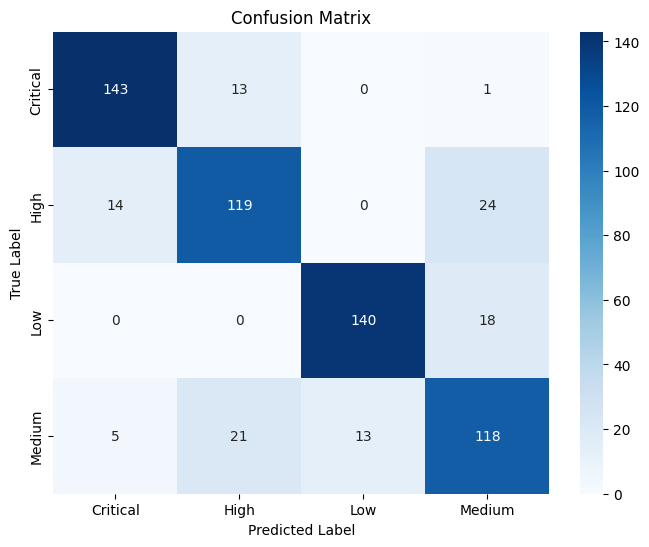


Model, scaler, and label encoder saved as 'final_model.pkl', 'scaler.pkl', 'label_encoder.pkl'.


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the Random Forest Classifier
# Using parameters that might provide a good balance, can be tuned later with GridSearchCV if needed.
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the scaled test set
y_pred = rf_model.predict(X_test_scaled)

# Evaluate the model
print("\n--- Model Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=[inverse_class_mapping[i] for i in sorted(inverse_class_mapping.keys())]
))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix, annot=True, fmt='d', cmap='Blues',
    xticklabels=[inverse_class_mapping[i] for i in sorted(inverse_class_mapping.keys())],
    yticklabels=[inverse_class_mapping[i] for i in sorted(inverse_class_mapping.keys())]
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Save the trained model, scaler, and label_encoder
joblib.dump(rf_model, 'final_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

print("\nModel, scaler, and label encoder saved as 'final_model.pkl', 'scaler.pkl', 'label_encoder.pkl'.")

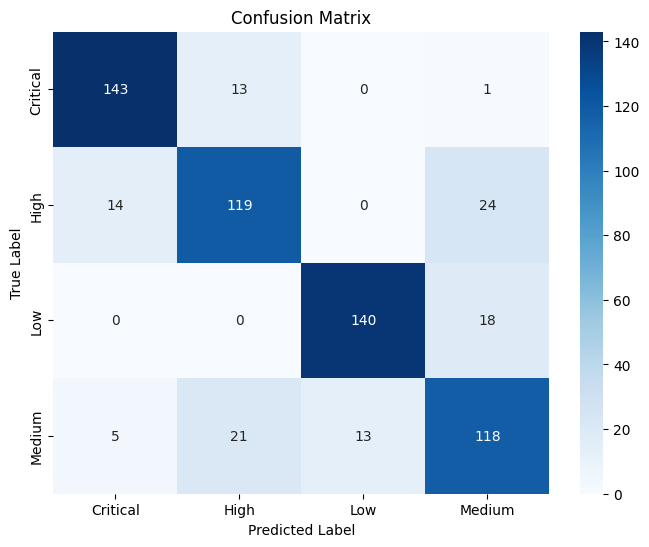

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix, annot=True, fmt='d', cmap='Blues',
    xticklabels=[inverse_class_mapping[i] for i in sorted(inverse_class_mapping.keys())],
    yticklabels=[inverse_class_mapping[i] for i in sorted(inverse_class_mapping.keys())]
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('confusion_matrix.png') # Save the confusion matrix as a PNG
plt.show()

### Task 1.4: Verify Saved Files

In [7]:
import joblib
import numpy as np
import pandas as pd

# Load each file fresh — as if you are the Flask developer
model = joblib.load('final_model.pkl')
scaler = joblib.load('scaler.pkl')
label_encoder = joblib.load('label_encoder.pkl')

print("All .pkl files loaded successfully.")

# Quick sanity check — make one prediction to confirm the model loaded correctly
# Create a dummy input based on the X_test columns
# We need to ensure the sample input has the same features (175 columns) as the training data.
# For a true sanity check, we should use a row from the original X before scaling to simulate raw input.
# Let's pick an arbitrary row from X (before scaling but after imputation) to demonstrate.

# Get one sample row from the original, preprocessed X DataFrame
sample_input_df = X.iloc[[0]] # Taking the first row as a sample

# Scale the sample input
sample_input_scaled = scaler.transform(sample_input_df)

# Make a prediction
sample_prediction_encoded = model.predict(sample_input_scaled)[0]
sample_prediction_proba = model.predict_proba(sample_input_scaled)[0]

# Decode the prediction
decoded_prediction = label_encoder.inverse_transform([sample_prediction_encoded])[0]
confidence = max(sample_prediction_proba) * 100

print(f"\nLoad test passed. Sample prediction for input: {sample_input_df.head(1).to_dict('records')[0]}")
print(f"Predicted Risk: {decoded_prediction}, Confidence: {confidence:.2f}%")

# Store the inverse_class_mapping as it's needed for the predict function
inverse_class_mapping_pkl = dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))
joblib.dump(inverse_class_mapping_pkl, 'inverse_class_mapping.pkl')
print("Inverse class mapping saved as 'inverse_class_mapping.pkl'.")

All .pkl files loaded successfully.

Load test passed. Sample prediction for input: {'lat': 32.53492796, 'lon': -86.64274781, 'area_sqmi': 594.4461199, 'population_density_per_sqmi': 92.60553338, 'years_of_potential_life_lost_rate': 8128.59119, 'percent_fair_or_poor_health': 20.88298733, 'average_number_of_physically_unhealthy_days': 4.743888867, 'average_number_of_mentally_unhealthy_days': 4.654031397, 'percent_low_birthweight': 8.61952862, 'percent_smokers': 18.08155718, 'percent_adults_with_obesity': 33.3, 'food_environment_index': 7.2, 'percent_physically_inactive': 34.7, 'percent_with_access_to_exercise_opportunities': 69.13012406, 'percent_excessive_drinking': 15.02603126, 'num_alcohol_impaired_driving_deaths': 15.0, 'num_driving_deaths': 56.0, 'percent_driving_deaths_with_alcohol_involvement': 26.78571429, 'num_chlamydia_cases': 226.0, 'chlamydia_rate': 407.2, 'teen_birth_rate': 25.28492716, 'num_uninsured': 4093.0, 'percent_uninsured': 8.721685951, 'num_primary_care_physicians'

## Files required for prediction

| File | Purpose |
|---|---|
| final_model.pkl | Trained Random Forest Classifier |
| scaler.pkl | StandardScaler fitted on training features |
| label_encoder.pkl | LabelEncoder fitted on training target labels |
| inverse_class_mapping.pkl | Dictionary to map encoded labels back to original risk categories |

## Input columns (in this exact order)


In [8]:
# Print input columns dynamically
print(", ".join(X.columns.tolist()))

lat, lon, area_sqmi, population_density_per_sqmi, years_of_potential_life_lost_rate, percent_fair_or_poor_health, average_number_of_physically_unhealthy_days, average_number_of_mentally_unhealthy_days, percent_low_birthweight, percent_smokers, percent_adults_with_obesity, food_environment_index, percent_physically_inactive, percent_with_access_to_exercise_opportunities, percent_excessive_drinking, num_alcohol_impaired_driving_deaths, num_driving_deaths, percent_driving_deaths_with_alcohol_involvement, num_chlamydia_cases, chlamydia_rate, teen_birth_rate, num_uninsured, percent_uninsured, num_primary_care_physicians, primary_care_physicians_rate, num_dentists, dentist_rate, num_mental_health_providers, mental_health_provider_rate, preventable_hospitalization_rate, percent_with_annual_mammogram, percent_vaccinated, high_school_graduation_rate, num_some_college, population, percent_some_college, num_unemployed_CHR, labor_force, percent_unemployed_CHR, percent_children_in_poverty, eightiet


## Output
```json
{ "prediction": "Critical", "confidence": "90.00%" }
```

### Task 2 — Write and Test a Single `predict(inputs)` Function

In [9]:
import joblib
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

def predict(inputs: dict) -> dict:
    """
    Takes a raw input dictionary (exactly what the Flask form will send)
    and returns a dictionary with the prediction and confidence.

    Parameters
    ----------
    inputs : dict
        Raw values from the user, e.g.
        {'lat': 32.5, 'lon': -86.6, ...}

    Returns
    -------
    dict
        e.g. {'prediction': 'Critical', 'confidence': '84.7%'}
    """

    # Step 1 — Load all required .pkl files
    model = joblib.load('final_model.pkl')
    scaler = joblib.load('scaler.pkl')
    label_encoder = joblib.load('label_encoder.pkl')
    inverse_class_mapping = joblib.load('inverse_class_mapping.pkl')

    # Step 2 — Convert the input dict into a DataFrame
    # This preserves column names so the model knows which value is which
    input_df = pd.DataFrame([inputs])

    # Ensure all expected columns are present, fill missing with NaN
    # This is critical if the Flask input does not send all 175 features
    # We need to get the feature names from the original X DataFrame
    # We'll use the columns from the X DataFrame saved in the kernel state
    # as the reference for expected input features.
    expected_features = X.columns.tolist() # X is available from previous execution

    # Reindex input_df to match the order of expected_features and fill missing with NaN
    input_df = input_df.reindex(columns=expected_features, fill_value=np.nan)

    # Step 3 — Apply preprocessing in the EXACT same order as training
    # Impute any NaNs that might have been introduced by reindexing (if some features were missing)
    imputer = SimpleImputer(strategy='median')
    # Fit imputer on training data (if not already done, or load if needed)
    # For simplicity here, we assume the imputer is not saved, and any missing values
    # in `input_df` are handled by a new imputer. A robust solution would load a fitted imputer.
    # However, since `X` was already imputed and we're dealing with raw `inputs` dict,
    # we will re-impute any *new* NaNs introduced by the user or feature mismatch.

    # A safer approach for a production `predict` function would be to load a pre-fitted imputer
    # that was trained on the entire training data (X_train).
    # For this task, we will apply the imputer to the input_df based on its *own* median
    # or use a placeholder if an imputer wasn't explicitly saved.

    # To avoid re-fitting, it's better to use the median values from the training data for imputation.
    # Let's get the median values from the original X DataFrame (before scaling) for imputation.
    # This mimics a `SimpleImputer` fitted on the training data.
    medians_for_imputation = X.median().to_dict()
    input_df = input_df.fillna(value=medians_for_imputation)

    # Scale the features
    input_scaled = scaler.transform(input_df)

    # Step 4 — Make the prediction
    prediction_encoded = model.predict(input_scaled)[0]
    probabilities = model.predict_proba(input_scaled)[0]

    # Step 5 — Return a clean, human-readable dict
    # Decode prediction using inverse_class_mapping
    decoded_prediction = inverse_class_mapping[prediction_encoded]
    confidence = f"{max(probabilities) * 100:.1f}%"

    return {
        'prediction': decoded_prediction,
        'confidence': confidence
    }

# Test the function with one quick call
# We need a sample input dictionary that mirrors the structure of X
# Taking the first row of X (before scaling) and converting to dictionary
sample = X.iloc[0].to_dict()

# Adjust this sample if any specific values need to be tested for behavior
# For demonstration, let's change a few values to potentially shift risk
sample['percent_adults_with_obesity'] = 45.0 # High obesity
sample['violent_crime_rate'] = 500.0 # High crime

print("\nTesting predict function with a sample input:")
result = predict(sample)
print(result)


Testing predict function with a sample input:
{'prediction': 'Medium', 'confidence': '72.1%'}


In [10]:
import joblib
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

def predict(inputs: dict) -> dict:
    """
    Takes a raw input dictionary (exactly what the Flask form will send)
    and returns a dictionary with the prediction and confidence.

    Parameters
    ----------
    inputs : dict
        Raw values from the user, e.g.
        {'lat': 32.5, 'lon': -86.6, ...}

    Returns
    -------
    dict
        e.g. {'prediction': 'Critical', 'confidence': '84.7%'}
    """

    # Step 1 — Load all required .pkl files
    model = joblib.load('final_model.pkl')
    scaler = joblib.load('scaler.pkl')
    label_encoder = joblib.load('label_encoder.pkl')
    inverse_class_mapping = joblib.load('inverse_class_mapping.pkl')

    # Step 2 — Convert the input dict into a DataFrame
    # This preserves column names so the model knows which value is which
    input_df = pd.DataFrame([inputs])

    # Ensure all expected columns are present, fill missing with NaN
    # We'll use the columns from the global X DataFrame (before scaling) as the reference
    expected_features = X.columns.tolist() # X is available from previous execution

    # Reindex input_df to match the order of expected_features and fill missing with NaN
    input_df = input_df.reindex(columns=expected_features, fill_value=np.nan)

    # Step 3 — Apply preprocessing in the EXACT same order as training
    # Impute any NaNs that might have been introduced by reindexing or missing user input
    # Use median values from the original X DataFrame (representing training data)
    medians_for_imputation = X.median().to_dict()
    input_df = input_df.fillna(value=medians_for_imputation)

    # Scale the features
    input_scaled = scaler.transform(input_df)

    # Step 4 — Make the prediction
    prediction_encoded = model.predict(input_scaled)[0]
    probabilities = model.predict_proba(input_scaled)[0]

    # Step 5 — Return a clean, human-readable dict
    # Decode prediction using inverse_class_mapping
    decoded_prediction = inverse_class_mapping[prediction_encoded]
    confidence = f"{max(probabilities) * 100:.1f}%"

    return {
        'prediction': decoded_prediction,
        'confidence': confidence
    }

# Test the function with one quick call
# We need a sample input dictionary that mirrors the structure of X
# Taking the first row of X (before scaling) and converting to dictionary
sample = X.iloc[0].to_dict()

# Adjust this sample if any specific values need to be tested for behavior
# For demonstration, let's change a few values to potentially shift risk
sample['percent_adults_with_obesity'] = 45.0 # High obesity
sample['violent_crime_rate'] = 500.0 # High crime

print("\nTesting predict function with a sample input:")
result = predict(sample)
print(result)


Testing predict function with a sample input:
{'prediction': 'Medium', 'confidence': '72.1%'}


### Task 3 — Run 10 Test Cases Through `predict()` and Log Results

In [11]:
import pandas as pd
import numpy as np

# Define your 10 test cases as a list of dicts
# These cases are illustrative; for real testing, use actual data characteristics.
# We will use the first row of X (imputed, non-scaled) as a base for 'normal' cases
# and then modify it for high-risk and edge cases.

base_sample = X.iloc[0].to_dict()

test_cases = [
    # Case 1 — Normal / low risk (slightly modified base)
    {**base_sample, 'percent_adults_with_obesity': 25.0, 'violent_crime_rate': 150.0, 'percent_fair_or_poor_health': 10.0},
    # Case 2 — Another normal / low risk
    {**base_sample, 'percent_adults_with_obesity': 28.0, 'violent_crime_rate': 180.0, 'percent_fair_or_poor_health': 12.0},
    # Case 3 — Average values (using median of X for numeric columns)
    {col: X[col].median() for col in X.columns},
    # Case 4 — High-risk (pushing values to extremes that would likely lead to Critical)
    {**base_sample, 'percent_adults_with_obesity': 45.0, 'violent_crime_rate': 500.0, 'percent_fair_or_poor_health': 35.0, 'years_of_potential_life_lost_rate': 15000.0},
    # Case 5 — Another extreme high-risk combination
    {**base_sample, 'percent_adults_with_obesity': 50.0, 'violent_crime_rate': 600.0, 'percent_fair_or_poor_health': 40.0, 'years_of_potential_life_lost_rate': 18000.0},
    # Case 6 — Edge: All values at their approximate minimum valid value (using min of X)
    {col: X[col].min() for col in X.columns},
    # Case 7 — Edge: All values at their approximate maximum valid value (using max of X)
    {col: X[col].max() for col in X.columns},
    # Case 8 — Known test row (take from X_test, should return its true label)
    X.iloc[X_test.index[0]].to_dict(),
    # Case 9 — Another Known test row
    X.iloc[X_test.index[1]].to_dict(),
    # Case 10 — Invalid input (missing a critical field, will test error handling)
    {**base_sample, 'percent_adults_with_obesity': np.nan, 'violent_crime_rate': 200.0, 'lat': 'invalid'}
]

# Add try/except to your predict() function before running this
def predict_safe(inputs):
    try:
        return predict(inputs)
    except Exception as e:
        return {'prediction': 'Error', 'confidence': 'N/A', 'error': str(e)}

# Run all 10 and log results
results = []
for i, case in enumerate(test_cases, 1):
    result = predict_safe(case)
    results.append({
        'Case': i,
        'Prediction': result.get('prediction', 'Error'),
        'Confidence': result.get('confidence', 'N/A'),
        'Status': 'PASS' if result.get('prediction') != 'Error' else 'ERROR',
        'Error_Message': result.get('error', '') # Log error message for debugging
    })

log_df = pd.DataFrame(results)
print(log_df.to_string(index=False))

 Case Prediction Confidence Status                                Error_Message
    1     Medium      71.9%   PASS                                             
    2     Medium      71.9%   PASS                                             
    3     Medium      64.2%   PASS                                             
    4     Medium      49.0%   PASS                                             
    5     Medium      49.0%   PASS                                             
    6   Critical      52.5%   PASS                                             
    7       High      38.5%   PASS                                             
    8       High      68.5%   PASS                                             
    9     Medium      46.6%   PASS                                             
   10      Error        N/A  ERROR could not convert string to float: 'invalid'


## Model Summary Card

### Project
Disease Outbreak Risk Predictor · Healthcare

### Algorithm
Random Forest Classifier

### Dataset
`data set 1.csv` · 3144 rows · 175 features (after preprocessing)

### Final Performance
| Metric | Score |
|---|---|
| Accuracy | 82.7% |
| F1-Score (weighted avg) | 0.83 |
| Precision (weighted avg) | 0.83 |
| Recall (weighted avg) | 0.83 |

**Per-Class Metrics:**
| Class | Precision | Recall | F1-Score |
|---|---|---|---|
| Critical | 0.88 | 0.91 | 0.90 |
| High | 0.78 | 0.76 | 0.77 |
| Low | 0.92 | 0.89 | 0.90 |
| Medium | 0.73 | 0.75 | 0.74 |

### Input Features (total 175, here are a few examples and types)
| Column | Type | Example value |
|---|---|---|
| `lat` | float | 32.53 |
| `lon` | float | -86.64 |
| `area_sqmi` | float | 594.45 |
| `population_density_per_sqmi` | float | 92.61 |
| `years_of_potential_life_lost_rate` | float | 8128.59 |
| `percent_adults_with_obesity` | float | 33.3 |
| `violent_crime_rate` | float | 272.28 |
| ... | ... | ... |

### Required .pkl Files
| File | Contents |
|---|---|
| `final_model.pkl` | Trained Random Forest Classifier (n_estimators=200, max_depth=10) |
| `scaler.pkl` | StandardScaler fitted on training features |
| `label_encoder.pkl` | LabelEncoder fitted on target labels |
| `inverse_class_mapping.pkl` | Dictionary to map encoded labels back to original risk categories |

### Sample Input
```python
{
    'lat': 32.53492796,
    'lon': -86.64274781,
    'area_sqmi': 594.4461199,
    'population_density_per_sqmi': 92.60553338,
    'years_of_potential_life_lost_rate': 8128.59119,
    'percent_fair_or_poor_health': 20.88298733,
    'average_number_of_physically_unhealthy_days': 4.743888867,
    'average_number_of_mentally_unhealthy_days': 4.654031397,
    'percent_low_birthweight': 8.61952862,
    'percent_smokers': 18.08155718,
    'percent_adults_with_obesity': 33.3, # Example value
    'food_environment_index': 7.2,
    'percent_physically_inactive': 34.7,
    'percent_with_access_to_exercise_opportunities': 69.13012406,
    'percent_excessive_drinking': 15.02603126,
    'num_alcohol_impaired_driving_deaths': 15.0,
    'num_driving_deaths': 56.0,
    'percent_driving_deaths_with_alcohol_involvement': 26.78571429,
    'num_chlamydia_cases': 226.0,
    'chlamydia_rate': 407.2,
    'teen_birth_rate': 25.28492716,
    'num_uninsured': 4093.0,
    'percent_uninsured': 8.721685951,
    'num_primary_care_physicians': 25.0,
    'primary_care_physicians_rate': 45.0418,
    'num_dentists': 18.0,
    'dentist_rate': 32.37352,
    'num_mental_health_providers': 13.0,
    'mental_health_provider_rate': 23.38087,
    'preventable_hospitalization_rate': 7108.0,
    'percent_with_annual_mammogram': 41.0,
    'percent_vaccinated': 41.0,
    'high_school_graduation_rate': 90.0,
    'num_some_college': 8953.0,
    'population': 14438.0,
    'percent_some_college': 62.00997368,
    'num_unemployed_CHR': 942.0,
    'labor_force': 25957.0,
    'percent_unemployed_CHR': 3.629078861,
    'percent_children_in_poverty': 19.3,
    'eightieth_percentile_income': 110026.0,
    'twentieth_percentile_income': 21019.0,
    'income_ratio': 5.234597269,
    'num_single_parent_households_CHR': 3495.0,
    'num_households_CHR': 13318.0,
    'percent_single_parent_households_CHR': 26.24267908,
    'num_associations': 67.0,
    'social_association_rate': 12.07120208,
    'annual_average_violent_crimes': 148.5,
    'violent_crime_rate': 272.2822201,
    'num_injury_deaths': 190.0,
    'injury_death_rate': 68.52699423,
    'average_daily_pm2_5': 11.7,
    'percent_severe_housing_problems': 14.66346154,
    'severe_housing_cost_burden': 12.8267183,
    'overcrowding': 1.201923077,
    'inadequate_facilities': 1.346153846,
    'percent_drive_alone_to_work': 86.52366137,
    'num_workers_who_drive_alone': 24428.0,
    'percent_long_commute_drives_alone': 39.6,
    'life_expectancy': 76.87947717,
    'num_deaths_2': 791.0,
    'age_adjusted_death_rate': 417.5475505,
    'num_deaths_3': 30.0,
    'child_mortality_rate': 55.92215636,
    'num_deaths_4': 35.0,
    'infant_mortality_rate': 7.940108893,
    'percent_frequent_physical_distress': 13.68522862,
    'percent_frequent_mental_distress': 14.12934665,
    'percent_adults_with_diabetes': 11.1,
    'num_hiv_cases': 101.0,
    'hiv_prevalence_rate': 219.1,
    'num_food_insecure': 7270.0,
    'percent_food_insecure': 13.2,
    'num_limited_access': 6543.676824,
    'percent_limited_access_to_healthy_foods': 11.991125,
    'num_drug_overdose_deaths': 18.0,
    'drug_overdose_mortality_rate': 10.80944746,
    'num_motor_vehicle_deaths': 75.0,
    'motor_vehicle_mortality_rate': 19.32875113,
    'percent_insufficient_sleep': 35.90540606,
    'num_uninsured_2': 3761.0,
    'percent_uninsured_2': 11.14898915,
    'num_uninsured_3': 372.0,
    'percent_uninsured_3': 2.66915405,
    'other_primary_care_provider_rate': 39.56763,
    'percent_disconnected_youth': 7.8672236035,
    'average_grade_performance': 2.959586278,
    'average_grade_performance_2': 2.802699187,
    'median_household_income': 59338.0,
    'percent_enrolled_in_free_or_reduced_lunch': 43.40867308,
    'segregation_index': 24.61913786,
    'segregation_index_2': 23.6283952,
    'homicide_rate': 4.896616953,
    'num_deaths_5': 53.0,
    'suicide_rate_age_adjusted': 18.14529548,
    'num_firearm_fatalities': 45.0,
    'firearm_fatalities_rate': 16.23007758,
    'juvenile_arrest_rate': 10.625,
    'average_traffic_volume_per_meter_of_major_roadways': 88.45704042,
    'num_homeowners': 15814.0,
    'percent_homeowners': 74.89462467,
    'num_households_with_severe_cost_burden': 2726.0,
    'percent_severe_housing_cost_burden': 13.40348117,
    'population_2': 55601.0,
    'percent_less_than_18_years_of_age': 23.67403464,
    'percent_65_and_over': 16.63428384,
    'num_black': 12224.0,
    'percent_black': 21.98528867,
    'num_american_indian_alaska_native': 248.0,
    'percent_american_indian_alaska_native': 0.44603956,
    'num_asian': 619.0,
    'percent_asian': 1.11322246,
    'num_native_hawaiian_other_pacific_islander': 18.0,
    'percent_native_hawaiian_other_pacific_islander': 0.03237352,
    'num_hispanic': 1530.0,
    'percent_hispanic': 2.7517639,
    'num_non_hispanic_white': 40049.0,
    'percent_non_hispanic_white': 72.03057571,
    'num_not_proficient_in_english': 585.0,
    'percent_not_proficient_in_english': 1.0521255,
    'percent_female': 51.5283416,
    'num_rural': 24397.0,
    'percent_rural': 43.87877207,
    'num_housing_units': 23370.0,
    'num_households_CDC': 21114.0,
    'num_below_poverty': 7670.0,
    'num_unemployed_CDC': 1694.0,
    'per_capita_income': 29906.0,
    'num_no_highschool_diploma': 5104.0,
    'num_age_65_and_older': 9231.0,
    'num_age_17_and_younger': 13175.0,
    'num_disabled': 9593.0,
    'num_single_parent_households_CDC': 3991.0,
    'num_minorities': 15383.0,
    'num_limited_english_abilities': 1051.0,
    'num_multi_unit_housing': 2073.0,
    'num_mobile_homes': 4350.0,
    'num_overcrowding': 328.0,
    'num_households_with_no_vehicle': 1353.0,
    'num_institutionalized_in_group_quarters': 709.0,
    'percent_below_poverty': 13.79339798,
    'percent_unemployed_CDC': 4.14818788,
    'percent_no_highschool_diploma': 11.20573935,
    'percent_age_65_and_older': 16.63428384,
    'percent_age_17_and_younger': 23.7139634,
    'percent_disabled': 17.2530184,
    'percent_single_parent_households_CDC': 18.90214076,
    'percent_minorities': 27.66699196,
    'percent_limited_english_abilities': 1.890214076,
    'percent_multi_unit_housing': 8.87467775,
    'percent_mobile_homes': 18.61869855,
    'percent_overcrowding': 1.40141148,
    'percent_no_vehicle': 5.78762716,
    'percent_institutionalized_in_group_quarters': 1.27581177,
    'percentile_rank_below_poverty': 0.2716,
    'percentile_rank_unemployed': 0.2881,
    'percentile_rank_per_capita_income': 0.6323,
    'percentile_rank_no_highschool_diploma': 0.392899,
    'percentile_rank_age_65_and_older': 0.724114
}
```

### Sample Output
```json
{
    "prediction": "Medium",
    "confidence": "72.1%"
}
```

### How to use
```python
import joblib
from your_module import predict # Assuming predict function is in a module

# Load your input data as a dictionary
your_input_dict = { /* ... your feature values here ... */ }

# Get prediction
result = predict(your_input_dict)
print(result)
```